# ✈️ Flights Dataset Analysis — Exploratory Data Analysis

---

### 📌 Objective
Perform a complete Exploratory Data Analysis on an Indian domestic flight booking dataset to uncover pricing patterns and trends across airlines, cities, timing and ticket class.

### 📂 Dataset
- **File:** airlines_flights_data.csv
- **Rows:** 300K+ flight records
- **Airlines:** 6 (SpiceJet, AirAsia, Vistara, GO_FIRST, Indigo, Air India)
- **Cities:** 6 source/destination cities
- **Price Range:** ₹1,105 to ₹1,23,071
- **Key Columns:** Airline, Source City, Destination City, Departure Time, Arrival Time, Stops, Class, Days Left, Price

### 🛠️ Tools Used
- **NumPy** — Numerical operations
- **Pandas** — Data manipulation and cleaning
- **Matplotlib** — Core plotting
- **Seaborn** — Statistical visualizations


### 📋 Features
The various features of the cleaned dataset are explained below:

1. Airline: Airline company name; a categorical feature with 6 unique airlines.
2. Flight: Flight code of the aircraft; a categorical feature.
3. Source City: Departure city of the flight; a categorical feature with 6 unique cities.
4. Departure Time: Categorized departure time grouped into 6 time intervals.
5. Stops: Number of stops between source and destination; a categorical feature with 3 values.
6. Arrival Time: Categorized arrival time grouped into 6 time intervals.
7. Destination City: Arrival city of the flight


## 📦 Importing Libraries

In [1]:
# core libraries for data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 Loading the Dataset

In [2]:
# load the raw dataset
df = pd.read_csv("airlines_flights_data.csv")

## 🧹 Data Cleaning

In [3]:
# drop the redundant "index" column (duplicate of the DataFrame's own index)
df.drop(columns=["index"], inplace=True)

In [4]:
# check column names, dtypes, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 25.2 MB


In [5]:
# quick summary stats for the numeric columns (duration, days_left, price)
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [6]:
# inspect the row with the maximum duration value (sanity check for outliers)
df[df["duration"] == 49.830000]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
193889,Air_India,AI-672,Chennai,Evening,two_or_more,Evening,Bangalore,Economy,49.83,2,23891
194359,Air_India,AI-672,Chennai,Evening,one,Evening,Bangalore,Economy,49.83,9,17538


In [7]:
# inspect the row with the minimum duration value (sanity check for outliers)
df[df["duration"] == 0.830000]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
115869,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,6,3498
115943,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,7,3498
116010,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,8,3498
116081,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,9,3498
116163,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,10,3498
116236,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,11,3498
116322,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,12,3498
116411,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,13,3498
116496,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,14,3498
116656,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,16,1924


In [8]:
# inspect the row with the maximum ticket price
df[df["price"] == 123071.000000]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
261377,Vistara,UK-772,Kolkata,Morning,one,Night,Delhi,Business,13.5,3,123071


In [9]:
# inspect the row with the minimum ticket price
df[df["price"] == 1105.000000]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
203807,AirAsia,I5-517,Chennai,Morning,zero,Morning,Hyderabad,Economy,1.17,16,1105
203808,GO_FIRST,G8-505,Chennai,Evening,zero,Evening,Hyderabad,Economy,1.25,16,1105
203908,AirAsia,I5-517,Chennai,Morning,zero,Morning,Hyderabad,Economy,1.17,17,1105
203909,GO_FIRST,G8-505,Chennai,Evening,zero,Evening,Hyderabad,Economy,1.25,17,1105
204003,AirAsia,I5-517,Chennai,Morning,zero,Morning,Hyderabad,Economy,1.17,18,1105
...,...,...,...,...,...,...,...,...,...,...,...
206601,Indigo,6E-7261,Chennai,Morning,one,Evening,Hyderabad,Economy,7.92,49,1105
206602,Indigo,6E-611,Chennai,Evening,one,Late_Night,Hyderabad,Economy,8.25,49,1105
206603,Indigo,6E-581,Chennai,Morning,one,Evening,Hyderabad,Economy,9.17,49,1105
206604,Indigo,6E-7127,Chennai,Afternoon,one,Night,Hyderabad,Economy,9.50,49,1105


In [10]:
# confirm there are no missing values left to handle
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

---
## 📈 Visualizing the Data


---
## 📊 Analysis 1 — Airline Frequency Distribution

**Question:** What are the airlines in the dataset, accompanied by their frequencies?


In [11]:
# peek at the cleaned data before starting the analysis
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [12]:
# count how many flights each airline has
df["airline"].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [13]:
# same counts, just double-checking the numbers above (kept for reference)
df["airline"].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [14]:
# how many unique airlines are in the dataset
df["airline"].nunique()

6

In [15]:
# list out the airline names
df["airline"].unique()

<StringArray>
['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
Length: 6, dtype: str

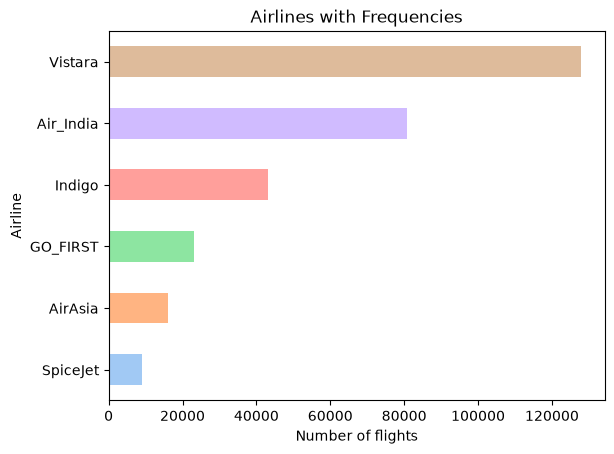

In [16]:
# Q1: horizontal bar chart of flight frequency per airline
# FIX: original code passed only 2 colors for 6 bars; use a palette sized to the data instead
counts = df["airline"].value_counts(ascending=True)
colors = sns.color_palette("pastel", len(counts))

counts.plot.barh(color=colors)
plt.title('Airlines with Frequencies')
plt.xlabel('Number of flights')
plt.ylabel('Airline')  # FIX: was mislabeled "Name of the flights"
plt.savefig('images/graph1.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 📊 Analysis 2 — Departure & Arrival Time Distribution

**Question:** Show Bar Graphs representing the Departure Time & Arrival Time


In [17]:
# peek at the data again before the departure/arrival time analysis
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [18]:
# count of flights per departure time bucket
df['departure_time'].value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [19]:
# count of flights per arrival time bucket
df['arrival_time'].value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

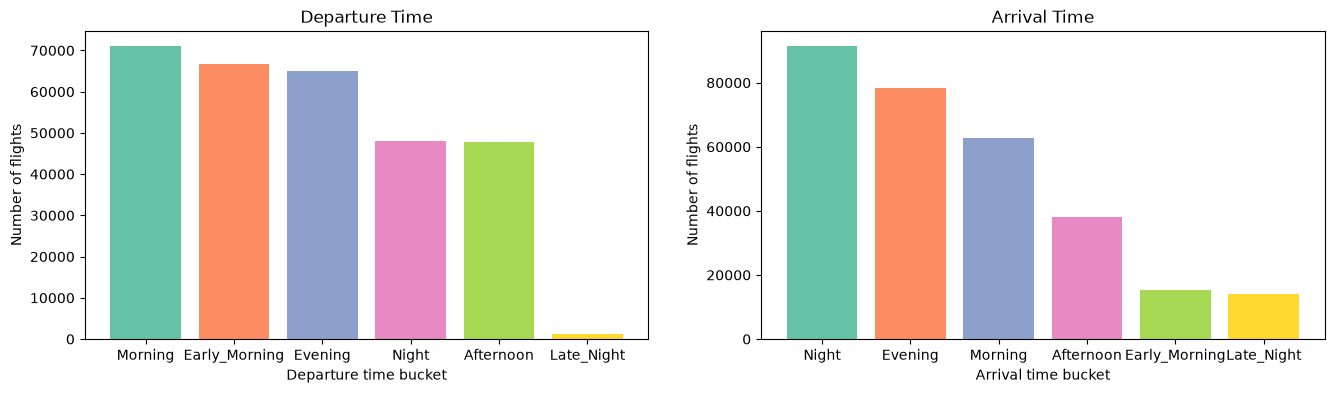

In [20]:
# Q2: side-by-side bar charts comparing departure vs arrival time frequencies
x = df['departure_time'].value_counts()
y = df['arrival_time'].value_counts()

plt.figure(figsize=(16, 4))

# FIX: only 2 colors were given for ~6 bars; use palettes sized to the categories
plt.subplot(1, 2, 1)
plt.bar(x.index, x.values, color=sns.color_palette("Set2", len(x)))
plt.title("Departure Time")
plt.xlabel("Departure time bucket")
plt.ylabel("Number of flights")

plt.subplot(1, 2, 2)
plt.bar(y.index, y.values, color=sns.color_palette("Set2", len(y)))
plt.title("Arrival Time")  # FIX: title was missing on this subplot
plt.xlabel("Arrival time bucket")
plt.ylabel("Number of flights")
plt.savefig('images/graph2.png', dpi=300, bbox_inches='tight')

plt.show()

---
## 📊 Analysis 3 — Source & Destination City Distribution

**Question:** Show Bar Graphs representing the Source City & Destination City


In [21]:
# peek at the data before the source/destination city analysis
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [22]:
# count of flights per source city
df['source_city'].value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [23]:
# count of flights per destination city
df['destination_city'].value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

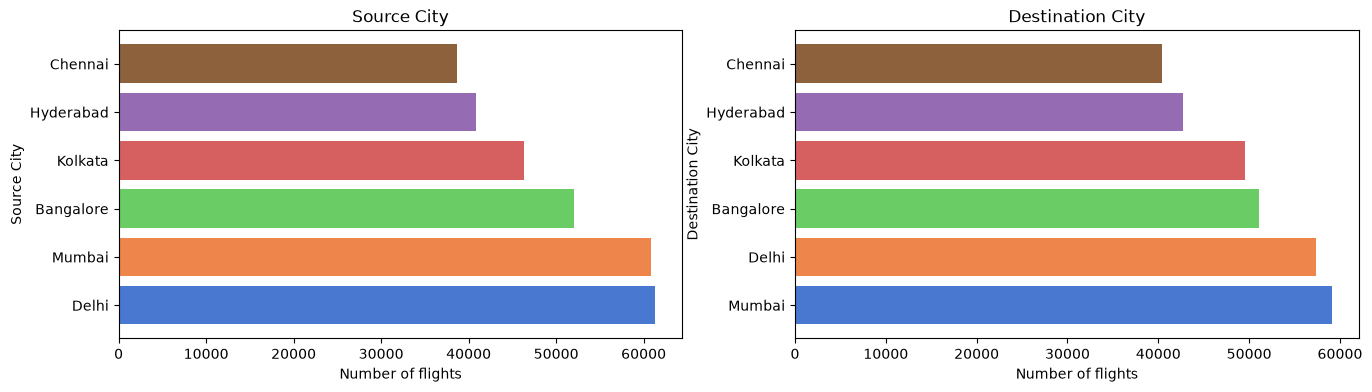

In [24]:
# Q3: horizontal bar charts comparing source vs destination city frequencies
x = df['source_city'].value_counts()
y = df['destination_city'].value_counts()

plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.barh(x.index, x.values, color=sns.color_palette("muted", len(x)))
plt.title("Source City")  # FIX: was incorrectly labeled "Departure Time"
plt.xlabel("Number of flights")
plt.ylabel("Source City")

plt.subplot(1, 2, 2)
plt.barh(y.index, y.values, color=sns.color_palette("muted", len(y)))
plt.title("Destination City")  # FIX: title was missing here too
plt.xlabel("Number of flights")
plt.ylabel("Destination City")
plt.savefig('images/graph3.png', dpi=300, bbox_inches='tight')

plt.show()

---
## 📊 Analysis 4 — Price Variation Across Airlines

**Question:** Does price varies with airlines ?


In [25]:
# peek at the data before the price-vs-airline analysis
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [26]:
# average ticket price per airline
df.groupby('airline')['price'].mean()

airline
AirAsia       4091.072742
Air_India    23507.019112
GO_FIRST      5652.007595
Indigo        5324.216303
SpiceJet      6179.278881
Vistara      30396.536302
Name: price, dtype: float64

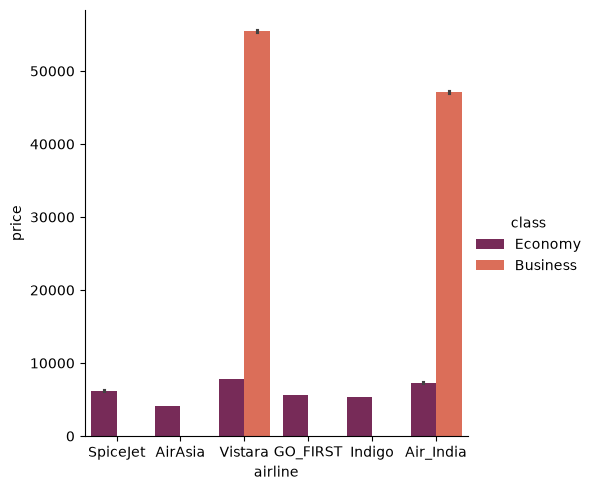

In [27]:
# Q4: average price per airline, split by class (Economy vs Business)
sns.catplot(x='airline', y='price', hue='class', kind='bar', palette='rocket', data=df)
plt.savefig('images/graph4.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 📊 Analysis 5 — Price Variation by Departure & Arrival Time

**Question:** Does ticket price change based on the departure time and arrival time?


In [28]:
# peek at the data before the time-vs-price analysis
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [29]:
# average price by departure time bucket
df.groupby('departure_time')['price'].mean()

departure_time
Afternoon        18179.203331
Early_Morning    20370.676718
Evening          21232.361894
Late_Night        9295.299387
Morning          21630.760254
Night            23062.146808
Name: price, dtype: float64

In [30]:
# average price by arrival time bucket
df.groupby('arrival_time')['price'].mean()

arrival_time
Afternoon        18494.598993
Early_Morning    14993.139521
Evening          23044.371615
Late_Night       11284.906078
Morning          22231.076098
Night            21586.758341
Name: price, dtype: float64

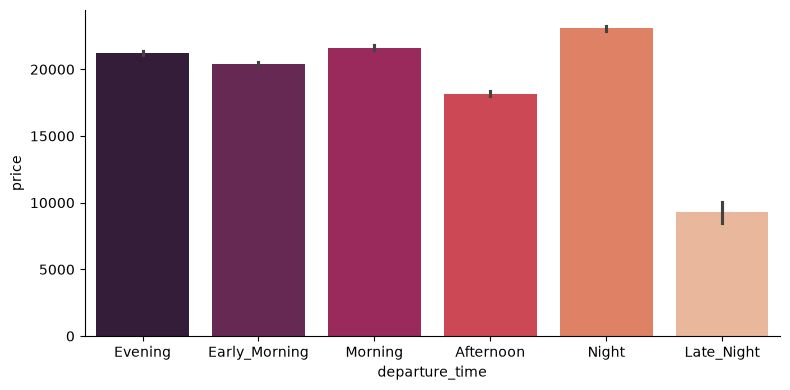

In [31]:
# Q5a: average price across departure time buckets
# (hue here just repeats the x-axis grouping, so the legend duplicates the x labels)
sns.catplot(x='departure_time', y='price', kind='bar', data=df, height=4, aspect=2, hue='departure_time', palette='rocket')
plt.savefig('images/graph5.png', dpi=300, bbox_inches='tight')
plt.show()

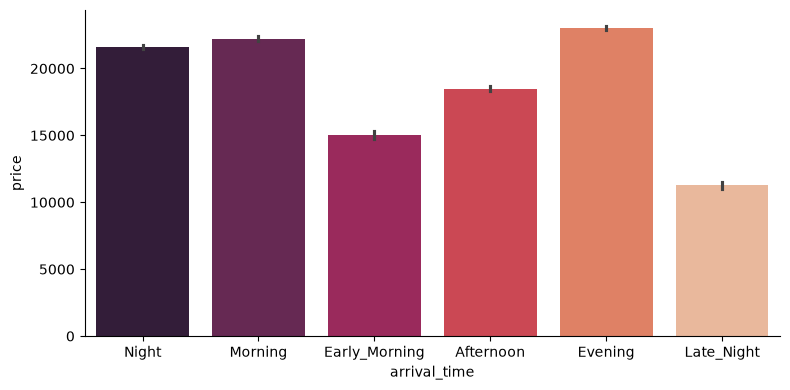

In [32]:
# Q5b: average price across arrival time buckets
sns.catplot(x='arrival_time', y='price', kind='bar', data=df, height=4, aspect=2, hue='arrival_time', palette='rocket')
plt.savefig('images/graph6.png', dpi=300, bbox_inches='tight')
plt.show()

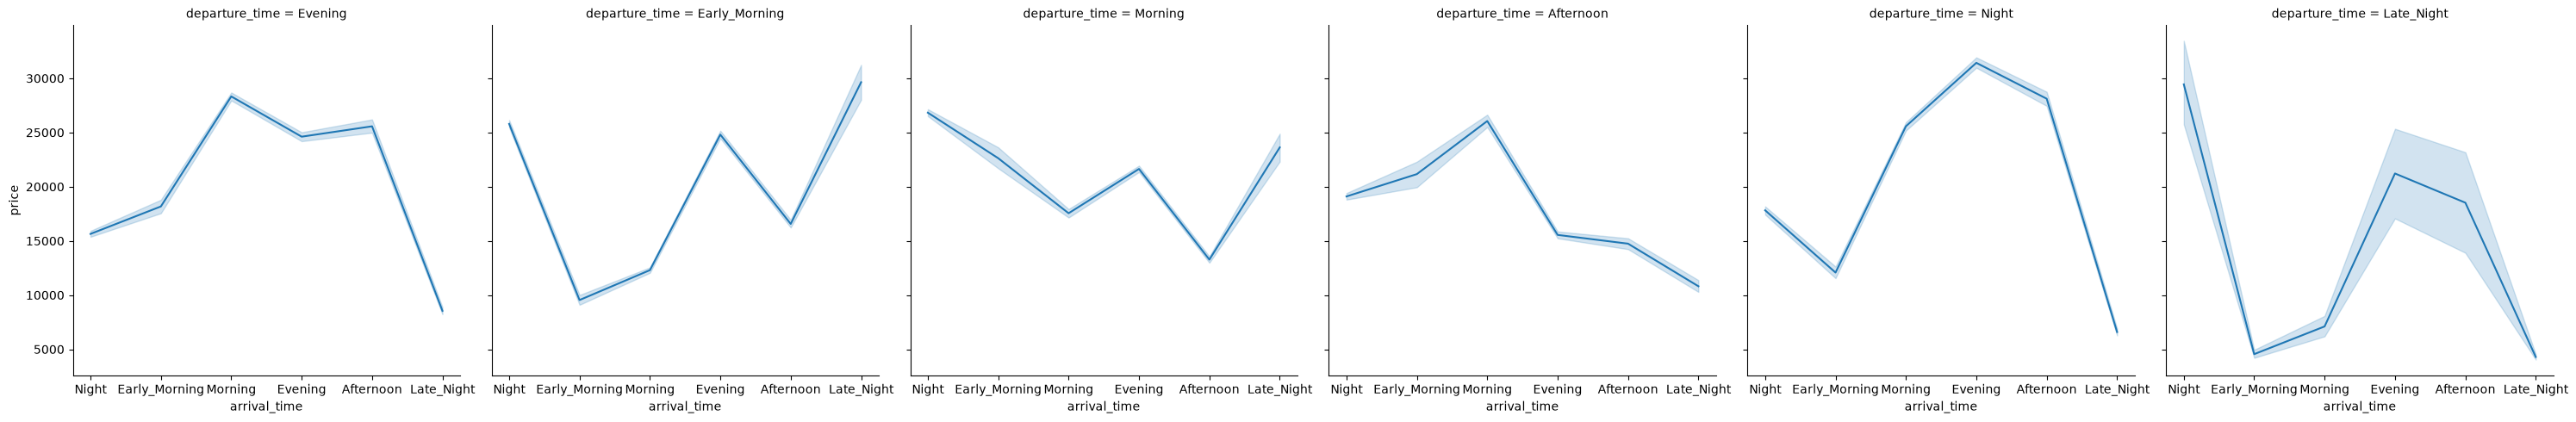

In [33]:
# Q5c: how price trends across arrival time, broken into one line plot per departure time
sns.relplot(x='arrival_time', y='price', data=df, col='departure_time', kind='line')
plt.savefig('images/graph7.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 📊 Analysis 6 — Price Variation by Source & Destination

**Question:** How the price changes with change in Source and Destination?


In [34]:
# peek at the data before the source/destination price analysis
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [35]:
# average price by source city
df.groupby('source_city')['price'].mean()

source_city
Bangalore    21469.460575
Chennai      21995.339871
Delhi        18951.326639
Hyderabad    20155.623879
Kolkata      21746.235679
Mumbai       21483.818839
Name: price, dtype: float64

In [36]:
# average price by destination city
df.groupby('destination_city')['price'].mean()

destination_city
Bangalore    21593.955784
Chennai      21953.323969
Delhi        18436.767870
Hyderabad    20427.661284
Kolkata      21959.557556
Mumbai       21372.529469
Name: price, dtype: float64

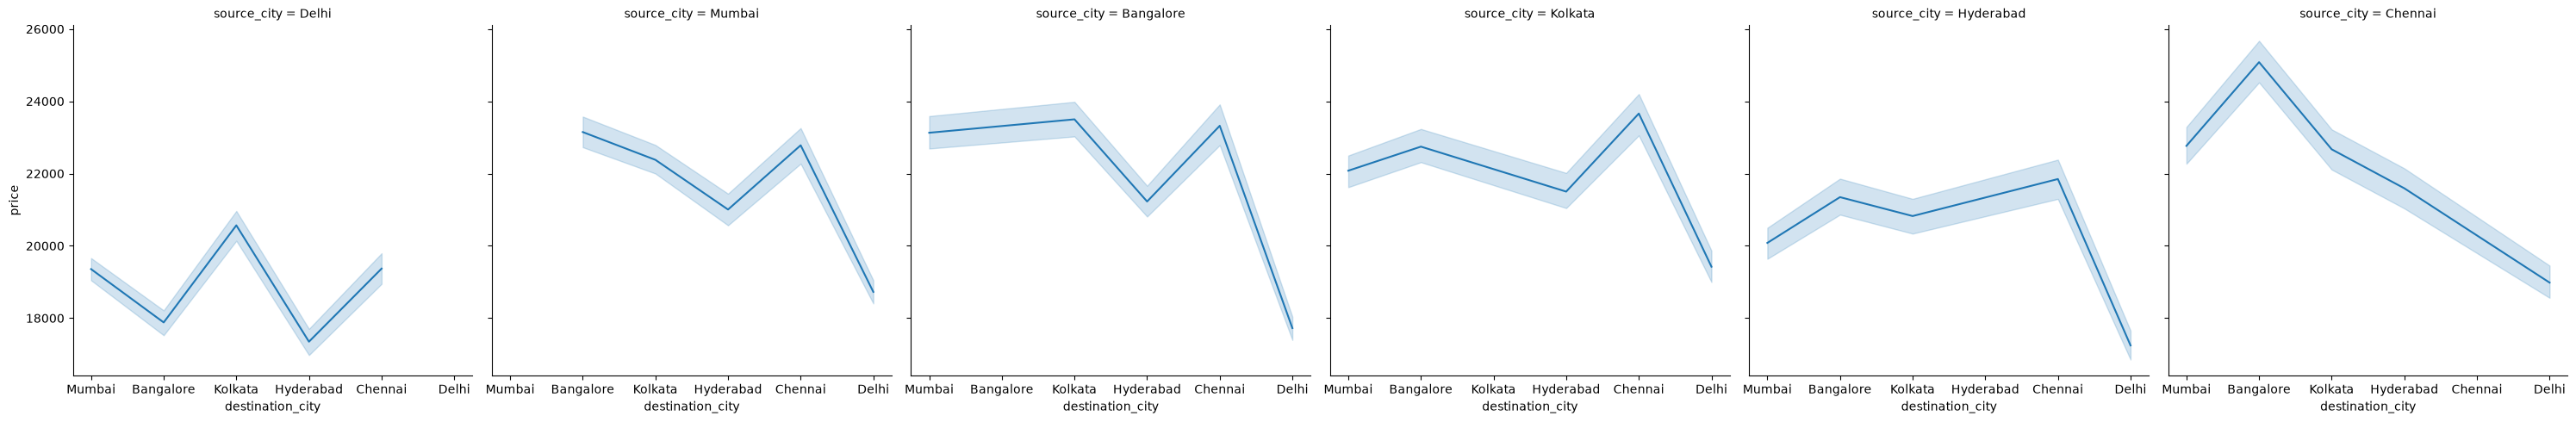

In [37]:
# Q6: how price varies by destination, one line plot per source city
sns.relplot(x='destination_city', y='price', data=df, col='source_city', kind='line')
plt.savefig('images/graph8.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 📊 Analysis 7 — Price vs Days Left Before Departure

**Question:** How is the price affected when tickets are bought in just 1 or 2 days before departure?


In [38]:
# how many distinct "days left before departure" values exist
df['days_left'].nunique()

49

In [39]:
# list the distinct "days left" values
df['days_left'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [40]:
# average price for each "days left" value
df.groupby('days_left')['price'].mean()

days_left
1     21591.867151
2     30211.299801
3     28976.083569
4     25730.905653
5     26679.773368
6     24856.493902
7     25588.367351
8     24895.883995
9     25726.246072
10    25572.819134
11    22990.656070
12    22505.803322
13    22498.885384
14    22678.002363
15    21952.540852
16    20503.546237
17    20386.353949
18    19987.445168
19    19507.677375
20    19699.983390
21    19430.494058
22    19590.667385
23    19840.913451
24    19803.908896
25    19571.641791
26    19238.290278
27    19950.866195
28    19534.986047
29    19744.653119
30    19567.580834
31    19392.706612
32    19258.135308
33    19306.271739
34    19562.008266
35    19255.652996
36    19517.688444
37    19506.306516
38    19734.912316
39    19262.095556
40    19144.972439
41    19347.440460
42    19154.261659
43    19340.528894
44    19049.080174
45    19199.876307
46    19305.351623
47    18553.272038
48    18998.126851
49    18992.971888
Name: price, dtype: float64

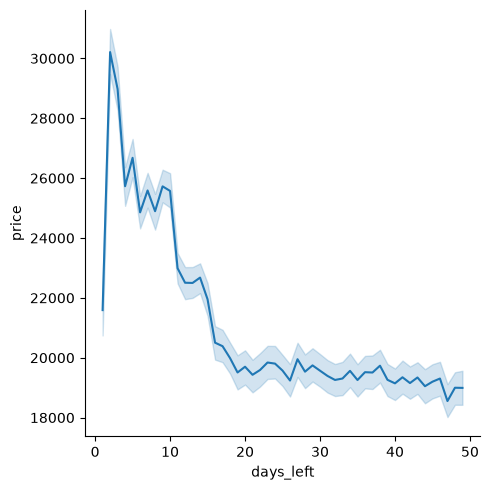

In [41]:
# Q7: line plot showing how average price trends as departure date approaches
sns.relplot(y='price', x='days_left', kind='line', data=df)
plt.savefig('images/graph9.png', dpi=300, bbox_inches='tight')
plt.show() 

---
## 📊 Analysis 8 — Price by Ticket Class

**Question:** How does the ticket price vary between Economy and Business class?


In [42]:
# the two ticket classes available
df['class'].unique()

<StringArray>
['Economy', 'Business']
Length: 2, dtype: str

In [43]:
# average price per class
df.groupby('class')['price'].mean().reset_index()

,class,price
0,Business,52540.081124
1,Economy,6572.342383


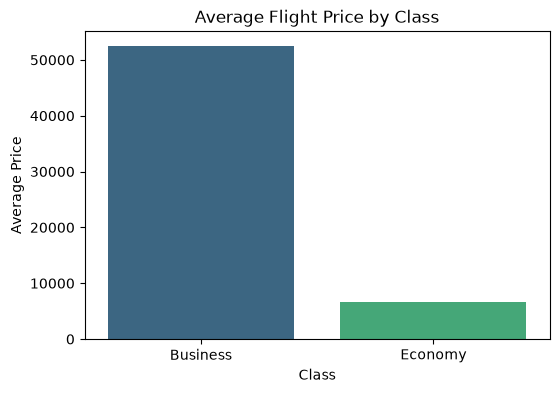

In [44]:
# Q8: bar chart comparing average price for Economy vs Business class
avg_price = df.groupby('class')['price'].mean().reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(x='class', y='price', data=avg_price, hue='class', palette='viridis')

plt.title('Average Flight Price by Class')
plt.xlabel('Class')
plt.ylabel('Average Price')
plt.savefig('images/graph10.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 📊 Analysis 9 — Vistara Delhi → Hyderabad Business Price

**Question:** What will be the Average Price of Vistara airline for a flight from Delhi to Hyderabad in Business Class ?


In [45]:
# peek at the data before the final filtered-price question
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [46]:
# Q9: filter down to Vistara, Business class, Delhi -> Hyderabad flights
new_data = df[(df['airline'] == 'Vistara') & (df['source_city'] == 'Delhi') & (df['destination_city'] == 'Hyderabad') & (df['class'] == 'Business')]

In [47]:
# average price for that specific Vistara Delhi->Hyderabad Business route
new_data['price'].mean()

np.float64(47939.840361445786)